# Chicago Curio model analysis

This is a notebook version of Curio project `b4a2907d-bf08-469f-a4d5-761f59c9f531` at saved graph revision **92**. It follows the graph from installed source paths through feature construction, the selected eight-family Chicago-only model, 90%-variance PCA, and the three similarity views. It is organized like `model_analysis.ipynb` so the São Paulo and Chicago calculations can be read side by side.

The graph contains the original **13 feature families plus BV**, a separate gridded-height feature. All 14 are shown below. A feature being calculated for Chicago does **not** mean it has been accepted for a cross-city model. The current PCA candidate uses M1, M6, B1, BV, U1, U2, U3, and U4.

## Run this notebook

Use the repository `.venv` kernel. The notebook reads installed local datasets from the sibling `curio/datasets` directory; set `CURIO_ROOT` if Curio lives elsewhere. No network fetch or saved Curio session is needed. Running every cell reconstructs the feature tables and model from source data, so geometry-heavy cells can take several minutes.

The code cells below embed the Python bodies of the saved Curio nodes. The small `curio_dataset_path` function replaces Curio's catalog path resolver; merge nodes become Python lists or tuples. This preserves the computation while making the notebook runnable outside the Curio canvas.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display

def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'analysis/model_analysis.py').is_file():
            return candidate
    raise FileNotFoundError('Open this notebook from the sideseeing-network repository.')

PROJECT_ROOT = find_project_root()
CURIO_ROOT = Path(os.environ.get('CURIO_ROOT', PROJECT_ROOT.parent / 'curio')).expanduser().resolve()
DATASET_ROOT = CURIO_ROOT / 'datasets'
if not DATASET_ROOT.is_dir():
    raise FileNotFoundError(f'Curio installed datasets were not found at {DATASET_ROOT}')

def curio_dataset_path(dataset_id):
    folder = DATASET_ROOT / f'{dataset_id}@1' / 'data'
    files = [path for path in folder.iterdir() if path.is_file()] if folder.is_dir() else []
    if len(files) != 1:
        raise FileNotFoundError(f'Expected exactly one installed data file for {dataset_id}: {files}')
    return str(files[0])

def feature_preview(label, value):
    frame = value[0] if isinstance(value, tuple) else value
    columns = [c for c in frame if c in ('unit_id', 'value', 'status') or c.startswith(label + '_')]
    print(f'{label}: {len(frame)} Community Areas')
    if 'status' in frame:
        print('Status:', frame.status.value_counts(dropna=False).to_dict())
    display(frame[columns].head(5))

## 1. Source nodes and three source bundles

Curio's source nodes return **paths**, so each feature reads only the columns it needs. The three bundles below mirror the canvas merge nodes: morphology receives Community Areas, Overture roads/connectors, and municipal streets; built form receives Community Areas, hydrography, building/height sources, and Cook records; urban function receives Community Areas, Census support, CMAP land use, and CTA GTFS. Repeating the boundary path across lanes keeps each branch independently readable.

In [2]:
def load_morph_areas():
    # Morphology · community areas. Paths only: each feature opens the data it needs.
    return {
        'community_areas': curio_dataset_path("data.cityofchicago.community-areas-sideseeing"),
    }

def load_morph_roads():
    # Morphology · Overture roads. Paths only: each feature opens the data it needs.
    return {
        'overture_segments': curio_dataset_path("data.overture.transportation-segments-chicago"),
        'overture_connectors': curio_dataset_path("data.overture.transportation-connectors-chicago"),
    }

def load_morph_streets():
    # Morphology · municipal streets. Paths only: each feature opens the data it needs.
    return {
        'street_centerlines': curio_dataset_path("data.cityofchicago.street-center-lines"),
    }

def load_built_areas():
    # Built form · community areas. Paths only: each feature opens the data it needs.
    return {
        'community_areas': curio_dataset_path("data.cityofchicago.community-areas-sideseeing"),
    }

def load_built_water():
    # Built form · hydrography. Paths only: each feature opens the data it needs.
    return {
        'hydrography': curio_dataset_path("data.cityofchicago.hydrography-sideseeing"),
    }

def load_built_footprints():
    # Built form · footprints and height. Paths only: each feature opens the data it needs.
    return {
        'city_building_footprints': curio_dataset_path("data.cityofchicago.building-footprints"),
        'overture_buildings': curio_dataset_path("data.overture.building-layers-chicago"),
        'ghsl_anbh_2018': curio_dataset_path("data.ghsl.chicago-h-anbh-e2018"),
    }

def load_built_cook():
    # Built form · Cook parcel records. Paths only: each feature opens the data it needs.
    return {
        'cook_buildings_2022': curio_dataset_path("data.sideseeing.cook-buildings-2022"),
        'cook_parcels_2024': curio_dataset_path("data.sideseeing.cook-parcels-2024"),
        'cook_universe_2024': curio_dataset_path("data.sideseeing.cook-universe-2024"),
        'cook_residential_2024': curio_dataset_path("data.sideseeing.cook-residential-2024"),
        'cook_condo_2024': curio_dataset_path("data.sideseeing.cook-condo-2024"),
        'cook_commercial_2024': curio_dataset_path("data.sideseeing.cook-commercial-2024"),
        'cook_commercial_details_2024': curio_dataset_path("data.sideseeing.cook-commercial-workbook-details-2024"),
    }

def load_urban_areas():
    # Urban function · community areas. Paths only: each feature opens the data it needs.
    return {
        'community_areas': curio_dataset_path("data.cityofchicago.community-areas-sideseeing"),
    }

def load_urban_census():
    # Urban function · Census support. Paths only: each feature opens the data it needs.
    return {
        'census_blocks_pop20_jobs': curio_dataset_path("data.census.chicago-blocks-pop20-lodes-2022"),
        'illinois_lodes_wac_2022': curio_dataset_path("data.census.illinois-lodes-wac-2022"),
        'acs_community_areas_diagnostic': curio_dataset_path("data.sideseeing.chicago-acs-community-areas"),
    }

def load_urban_land_use():
    # Urban function · CMAP land use. Paths only: each feature opens the data it needs.
    return {
        'cmap_land_use_2023': curio_dataset_path("data.cmap.land-use-inventory-chicago"),
    }

def load_urban_transit():
    # Urban function · CTA GTFS. Paths only: each feature opens the data it needs.
    return {
        'cta_agency': curio_dataset_path("data.cta.gtfs-chicago-agency"),
        'cta_routes': curio_dataset_path("data.cta.gtfs-chicago-routes"),
        'cta_trips': curio_dataset_path("data.cta.gtfs-chicago-trips"),
        'cta_stops': curio_dataset_path("data.cta.gtfs-chicago-stops"),
        'cta_stop_times': curio_dataset_path("data.cta.gtfs-chicago-stop-times"),
        'cta_calendar': curio_dataset_path("data.cta.gtfs-chicago-calendar"),
        'cta_calendar_dates': curio_dataset_path("data.cta.gtfs-chicago-calendar-dates"),
    }

In [3]:
morph_sources = [load_morph_areas(), load_morph_roads(), load_morph_streets()]
built_sources = [load_built_areas(), load_built_water(), load_built_footprints(), load_built_cook()]
urban_sources = [load_urban_areas(), load_urban_census(), load_urban_land_use(), load_urban_transit()]

for lane, bundle in [('Morphology', morph_sources), ('Built form', built_sources),
                     ('Urban function', urban_sources)]:
    print(lane, '—', sum(len(slot) for slot in bundle), 'installed source paths')

Morphology — 4 installed source paths
Built form — 12 installed source paths
Urban function — 12 installed source paths


## 2. Morphology features

### M1 — mapped street density

Measures eligible Overture road length inside each Community Area divided by gross area. Boundary-coincident pieces are assigned once. Its output also keeps class-specific lengths for M6. Included in the Chicago-only model, but source and class rules are not yet harmonized with São Paulo.

In [4]:
def build_m1(arg):
    # M1: mapped street length per gross square kilometre. arg is the morphology lane: area, Overture roads, municipal streets.
    import geopandas as gpd
    import numpy as np
    import pandas as pd
    import shapely
    areas=gpd.read_file(arg[0]['community_areas']).to_crs(26916)
    areas['unit_id']='CHI:'+areas.area_numbe.astype(int).astype(str).str.zfill(2)
    areas=areas[['unit_id','geometry']].sort_values('unit_id').reset_index(drop=True)
    assert len(areas)==areas.unit_id.nunique()==77
    classes=['motorway','trunk','primary','secondary','tertiary','residential','living_street','pedestrian','unclassified','unknown']
    roads=gpd.read_parquet(arg[1]['overture_segments'],columns=['id','subtype','class','geometry'])
    roads=roads.loc[roads.subtype.eq('road')&roads['class'].isin(classes)].to_crs(26916).reset_index(drop=True)
    assert roads.id.is_unique and roads.geometry.is_valid.all()
    roads=roads.iloc[roads.sindex.query(areas.geometry.union_all(),predicate='intersects')].reset_index(drop=True)
    rows=[]; class_rows=[]
    for area in areas.itertuples():
        ids=roads.sindex.query(area.geometry,predicate='intersects')
        geom=roads.geometry.values[ids]
        inside=shapely.covers(area.geometry,geom)
        clipped=np.array(geom,copy=True)
        clipped[~inside]=shapely.intersection(geom[~inside],area.geometry)
        prior=areas.loc[areas.unit_id.lt(area.unit_id)]
        neighbors=prior.iloc[prior.sindex.query(area.geometry,predicate='intersects')]
        shared=shapely.union_all([area.geometry.boundary.intersection(g.boundary) for g in neighbors.geometry])
        if not shared.is_empty: clipped=shapely.difference(clipped,shared)
        lengths=shapely.length(clipped)
        total=float(lengths.sum()); gross=float(area.geometry.area)
        if total<=0 or gross<=0: raise ValueError(area.unit_id+' empty road or area support')
        rows.append({'unit_id':area.unit_id,'M1_mapped_street_density_km_km2':total/1000/(gross/1e6),
                     'eligible_road_length_m':total,'gross_area_m2':gross,'status':'constructed_chicago'})
        for category in classes:
            class_rows.append({'unit_id':area.unit_id,'class':category,
                               'length_m':float(lengths[roads['class'].iloc[ids].eq(category).to_numpy()].sum())})
    summary=pd.DataFrame(rows); class_lengths=pd.DataFrame(class_rows)
    assert np.allclose(summary.set_index('unit_id').eligible_road_length_m,
                       class_lengths.groupby('unit_id').length_m.sum().reindex(summary.unit_id),atol=.01)
    return (summary,class_lengths)

m1 = build_m1(morph_sources)
feature_preview('M1', m1)

M1: 77 Community Areas
Status: {'constructed_chicago': 77}


,unit_id,M1_mapped_street_density_km_km2,status
0,CHI:01,13.202695,constructed_chicago
1,CHI:02,13.081954,constructed_chicago
2,CHI:03,10.690912,constructed_chicago
3,CHI:04,11.826708,constructed_chicago
4,CHI:05,13.955781,constructed_chicago


### M2 — connector candidate density

Counts Overture connectors with at least three incident road arms per gross square kilometre. A connector is a graph object, not necessarily one physical street intersection: divided roads, ramps, and grade separation still need review. Diagnostic only; excluded from the model.

In [5]:
def build_m2(arg):
    # M2: candidate graph connector density only. Physical intersection consolidation is unresolved.
    import geopandas as gpd
    import pandas as pd
    import numpy as np
    areas=gpd.read_file(arg[0]['community_areas']).to_crs(26916)
    areas['unit_id']='CHI:'+areas.area_numbe.astype(int).astype(str).str.zfill(2)
    areas=areas[['unit_id','geometry']].sort_values('unit_id').reset_index(drop=True)
    classes=['motorway','trunk','primary','secondary','tertiary','residential','living_street','pedestrian','unclassified','unknown']
    roads=gpd.read_parquet(arg[1]['overture_segments'],columns=['id','subtype','class','connectors','geometry'])
    roads=roads.loc[roads.subtype.eq('road')&roads['class'].isin(classes)]
    assert roads.id.is_unique
    arms={}
    for row in roads.itertuples():
        for link in row.connectors:
            at=float(link['at']); key=link['connector_id']
            if not np.isfinite(at) or not 0<=at<=1:raise ValueError('Bad connector position')
            bucket=arms.setdefault(key,set())
            if at>0:bucket.add((row.id,at,'before'))
            if at<1:bucket.add((row.id,at,'after'))
    connectors=gpd.read_parquet(arg[1]['overture_connectors'],columns=['id','geometry']).to_crs(26916)
    connectors=connectors.loc[connectors.id.map(lambda x:len(arms.get(x,()))>=3)].reset_index(drop=True)
    own=np.full(len(connectors),'',dtype=object)
    for area in areas.itertuples():
        ids=connectors.sindex.query(area.geometry,predicate='intersects')
        own[ids[own[ids]=='']]=area.unit_id
    counts=pd.Series(own[own!='']).value_counts()
    result=areas[['unit_id']].copy()
    result['M2_connector_candidate_density_km2']=result.unit_id.map(counts).fillna(0).to_numpy()/(areas.geometry.area.to_numpy()/1e6)
    result['status']='diagnostic_only_not_physical_intersections'
    return result

m2 = build_m2(morph_sources)
feature_preview('M2', m2)

M2: 77 Community Areas
Status: {'diagnostic_only_not_physical_intersections': 77}


,unit_id,M2_connector_candidate_density_km2,status
0,CHI:01,68.927021,diagnostic_only_not_physical_intersections
1,CHI:02,51.544936,diagnostic_only_not_physical_intersections
2,CHI:03,42.693723,diagnostic_only_not_physical_intersections
3,CHI:04,52.838435,diagnostic_only_not_physical_intersections
4,CHI:05,60.227394,diagnostic_only_not_physical_intersections


### M3 — mapped-street enclosure size

Polygonizes selected municipal street lines and summarizes the logarithm of enclosure area. These closed faces are not validated physical blocks and differ from São Paulo cadastral quadras. The node also returns the faces used by M4. Experimental; excluded.

In [6]:
def build_m3(arg):
    # M3: experimental mapped-street enclosures. These are not accepted physical blocks.
    import geopandas as gpd
    import pandas as pd
    import numpy as np
    import shapely
    areas=gpd.read_file(arg[0]['community_areas']).to_crs(26916)
    areas['unit_id']='CHI:'+areas.area_numbe.astype(int).astype(str).str.zfill(2)
    areas=areas[['unit_id','geometry']].sort_values('unit_id').reset_index(drop=True)
    assert len(areas)==areas.unit_id.nunique()==77
    streets=gpd.read_file(arg[2]['street_centerlines'])
    streets=streets.loc[streets.status.eq('N')&streets['class'].isin(['1','2','3','4','7','9','99'])]
    streets=streets.to_crs(26916)
    city=areas.geometry.union_all()
    streets=streets.iloc[streets.sindex.query(city.buffer(1500),predicate='intersects')]
    merged=shapely.union_all(streets.geometry.values)
    faces=shapely.get_parts(shapely.polygonize(shapely.get_parts(merged)))
    faces=np.array([g for g in faces if g.area>0 and g.intersects(city) and not g.boundary.intersects(city.boundary)],dtype=object)
    face_frame=gpd.GeoDataFrame({'face_id':range(len(faces))},geometry=faces,crs=26916)
    a,b=areas.sindex.query(face_frame.geometry,predicate='intersects')
    overlap=shapely.area(shapely.intersection(face_frame.geometry.values[a],areas.geometry.values[b]))
    q=pd.DataFrame({'face_id':a,'unit_id':areas.unit_id.values[b],'overlap_m2':overlap})
    q=q.loc[q.overlap_m2.gt(0)].sort_values(['face_id','overlap_m2','unit_id'],ascending=[True,False,True]).drop_duplicates('face_id')
    face_frame=face_frame.merge(q[['face_id','unit_id']],on='face_id',validate='one_to_one')
    face_frame['area_m2']=face_frame.geometry.area
    face_frame['log_area']=np.log(face_frame.area_m2)
    agg=face_frame.groupby('unit_id').log_area.agg(['median',lambda x:x.quantile(.75)-x.quantile(.25),'size'])
    agg.columns=['M3_log_area_median','M3_log_area_iqr','enclosure_candidates']
    result=areas[['unit_id']].join(agg,on='unit_id')
    result['status']='experimental_enclosures_not_accepted_blocks'
    return (result,face_frame[['unit_id','area_m2','geometry']])

m3 = build_m3(morph_sources)
feature_preview('M3', m3)

M3: 77 Community Areas
Status: {'experimental_enclosures_not_accepted_blocks': 77}


,unit_id,M3_log_area_median,M3_log_area_iqr,status
0,CHI:01,9.938330,0.414501,experimental_enclosures_not_accepted_blocks
1,CHI:02,9.914306,0.038536,experimental_enclosures_not_accepted_blocks
2,CHI:03,10.113795,0.624263,experimental_enclosures_not_accepted_blocks
3,CHI:04,9.923367,0.370298,experimental_enclosures_not_accepted_blocks
4,CHI:05,9.920132,0.070039,experimental_enclosures_not_accepted_blocks


### M4 — mapped-street enclosure shape

Uses the exact M3 faces to summarize compactness and elongation. Any missing barrier or extra line changes both the boundary and the shape. Because M3 faces are not accepted blocks, M4 is experimental and excluded.

In [7]:
def build_m4(arg):
    # M4 uses exactly the same experimental enclosures as M3.
    import pandas as pd
    import numpy as np
    import shapely
    m3,faces=arg
    compact=[];elong=[]
    for geom in faces.geometry:
        area=geom.area; perimeter=geom.length
        compact.append(4*np.pi*area/perimeter**2)
        r=shapely.minimum_rotated_rectangle(geom)
        coords=np.asarray(r.exterior.coords)
        sides=np.linalg.norm(np.diff(coords,axis=0),axis=1)
        elong.append(float(sides.max()/sides.min()))
    q=faces[['unit_id']].copy(); q['compactness']=compact; q['elongation']=elong
    agg=q.groupby('unit_id').agg(M4_compactness_median=('compactness','median'),
        M4_compactness_iqr=('compactness',lambda x:x.quantile(.75)-x.quantile(.25)),
        M4_elongation_median=('elongation','median'),
        M4_elongation_iqr=('elongation',lambda x:x.quantile(.75)-x.quantile(.25)))
    result=m3[['unit_id']].join(agg,on='unit_id')
    result['status']='experimental_enclosures_not_accepted_blocks'
    return result

m4 = build_m4(m3)
feature_preview('M4', m4)

M4: 77 Community Areas
Status: {'experimental_enclosures_not_accepted_blocks': 77}


,unit_id,M4_compactness_median,M4_compactness_iqr,M4_elongation_median,M4_elongation_iqr,status
0,CHI:01,0.734188,0.101332,1.585156,0.697225,experimental_enclosures_not_accepted_blocks
1,CHI:02,0.699988,0.007824,1.988104,0.082425,experimental_enclosures_not_accepted_blocks
2,CHI:03,0.699581,0.206247,1.823231,1.430421,experimental_enclosures_not_accepted_blocks
3,CHI:04,0.699973,0.057084,1.961424,0.643430,experimental_enclosures_not_accepted_blocks
4,CHI:05,0.697392,0.005835,2.002025,0.060522,experimental_enclosures_not_accepted_blocks


### M6 — street-class composition

Divides the M1 clipped length of each of ten Overture road classes by the same total eligible length. The shares sum to one and are treated as one Hellinger-composition family. Included in the Chicago-only model; the class ontology still differs from São Paulo.

In [8]:
def build_m6(arg):
    # M6 consumes the exact selected, clipped, boundary-owned lengths from M1.
    import numpy as np
    m1,lengths=arg
    classes=['motorway','trunk','primary','secondary','tertiary','residential','living_street','pedestrian','unclassified','unknown']
    wide=lengths.pivot(index='unit_id',columns='class',values='length_m').reindex(columns=classes)
    if wide.isna().any().any(): raise ValueError('Missing road class lengths')
    result=m1[['unit_id','eligible_road_length_m']].merge(wide,left_on='unit_id',right_index=True,validate='one_to_one')
    for c in classes: result['M6_share_'+c]=result[c]/result.eligible_road_length_m
    assert np.allclose(result.filter(like='M6_share_').sum(axis=1),1,atol=1e-9)
    result['status']='constructed_chicago'
    return result[['unit_id']+['M6_share_'+c for c in classes]+['eligible_road_length_m','status']]

m6 = build_m6(m1)
feature_preview('M6', m6)

M6: 77 Community Areas
Status: {'constructed_chicago': 77}


,unit_id,M6_share_motorway,M6_share_trunk,M6_share_primary,M6_share_secondary,M6_share_tertiary,M6_share_residential,M6_share_living_street,M6_share_pedestrian,M6_share_unclassified,M6_share_unknown,status
0,CHI:01,0.000000,0.0,0.000000,0.188444,0.105566,0.661844,0.002082,0.019867,0.004558,0.017639,constructed_chicago
1,CHI:02,0.000000,0.0,0.047105,0.116891,0.055740,0.766701,0.000000,0.000000,0.001248,0.012316,constructed_chicago
2,CHI:03,0.127872,0.0,0.027864,0.231392,0.110925,0.470667,0.006222,0.003580,0.000149,0.021329,constructed_chicago
3,CHI:04,0.000000,0.0,0.047449,0.167193,0.081127,0.678713,0.002774,0.000000,0.000000,0.022744,constructed_chicago
4,CHI:05,0.000000,0.0,0.045178,0.127048,0.079045,0.733263,0.000000,0.002168,0.000331,0.012966,constructed_chicago


## 3. Built form features

### M7 — cadastral parcel density

Returns an explicit missing value. Cook PINs, parent parcels, condominium units, and tax interests do not yet identify a single unduplicated physical entity, and DuPage support remains unresolved. Excluded.

In [9]:
def build_m7(arg):
    # M7: explicit unavailable state; no invented measurement.
    import geopandas as gpd
    import pandas as pd
    areas=gpd.read_file(arg[0]['community_areas'])
    ids='CHI:'+areas.area_numbe.astype(int).astype(str).str.zfill(2)
    assert len(ids)==ids.nunique()==77
    return pd.DataFrame({'unit_id':ids,'feature':['M7']*77,'value':[float('nan')]*77,
        'status':['not_constructed_source_or_entity_gate']*77,'reason':['Parcel density: Cook parcel, PIN, condo and assessment records do not yet define one citywide parcel entity without duplicate tax interests.']*77}).sort_values('unit_id')

m7 = build_m7(built_sources)
feature_preview('M7', m7)

M7: 77 Community Areas
Status: {'not_constructed_source_or_entity_gate': 77}


,unit_id,value,status
0,CHI:01,NaN,not_constructed_source_or_entity_gate
1,CHI:02,NaN,not_constructed_source_or_entity_gate
2,CHI:03,NaN,not_constructed_source_or_entity_gate
3,CHI:04,NaN,not_constructed_source_or_entity_gate
4,CHI:05,NaN,not_constructed_source_or_entity_gate


### B1 — mapped building coverage

Unions clipped Overture building footprints in tiles, subtracts mapped hydrography from the land denominator, and reports the occupied land fraction. The union prevents overlapping footprints from inflating area. Included in the Chicago-only model; temporal and cross-city footprint comparability remain open.

In [10]:
def build_b1(arg):
    # B1: exact footprint union on hydrographic land and gross area.
    import geopandas as gpd
    import pandas as pd
    import numpy as np
    import shapely
    areas=gpd.read_file(arg[0]['community_areas']).to_crs(26916)
    areas['unit_id']='CHI:'+areas.area_numbe.astype(int).astype(str).str.zfill(2)
    areas=areas[['unit_id','geometry']].sort_values('unit_id').reset_index(drop=True)
    assert len(areas)==areas.unit_id.nunique()==77
    water=gpd.read_file(arg[1]['hydrography']).to_crs(26916).geometry.union_all()
    buildings=gpd.read_parquet(arg[2]['overture_buildings'],columns=['id','geometry']).to_crs(26916)
    assert buildings.id.is_unique and buildings.geometry.is_valid.all()
    rows=[]
    for area in areas.itertuples():
        gross=area.geometry; land=gross.difference(water)
        gross_m2,land_m2=gross.area,land.area
        if gross_m2<=0 or land_m2<=0: raise ValueError(area.unit_id+' invalid land support')
        union_gross=union_land=summed=0.0
        xmin,ymin,xmax,ymax=gross.bounds
        for x in np.arange(np.floor(xmin/2000)*2000,xmax,2000):
            for y in np.arange(np.floor(ymin/2000)*2000,ymax,2000):
                tile=shapely.box(x,y,x+2000,y+2000).intersection(gross)
                if tile.area<=0: continue
                ids=buildings.sindex.query(tile,predicate='intersects')
                pieces=shapely.intersection(buildings.geometry.values[ids],tile)
                union=shapely.union_all(pieces)
                union_gross+=union.area; union_land+=union.intersection(land).area
                summed+=float(shapely.area(pieces).sum())
        if union_land>land_m2+.01 or union_gross>gross_m2+.01 or union_gross>summed+.01:
            raise ValueError(area.unit_id+' footprint bounds failed')
        rows.append({'unit_id':area.unit_id,'B1_coverage_land':union_land/land_m2,
                     'B1_coverage_gross':union_gross/gross_m2,'footprint_union_land_m2':union_land,
                     'footprint_union_gross_m2':union_gross,'summed_footprint_m2':summed,
                     'overlap_excess_fraction':(summed-union_gross)/summed if summed else 0,
                     'land_area_m2':land_m2,'gross_area_m2':gross_m2,'water_area_m2':gross_m2-land_m2,
                     'status':'constructed_chicago'})
    return pd.DataFrame(rows)

b1 = build_b1(built_sources)
feature_preview('B1', b1)

B1: 77 Community Areas
Status: {'constructed_chicago': 77}


,unit_id,B1_coverage_land,B1_coverage_gross,status
0,CHI:01,0.304009,0.304007,constructed_chicago
1,CHI:02,0.258198,0.257477,constructed_chicago
2,CHI:03,0.231816,0.231328,constructed_chicago
3,CHI:04,0.238479,0.235538,constructed_chicago
4,CHI:05,0.309258,0.304043,constructed_chicago


### B2 — reported floor-count distribution

Returns an explicit missing value. Reported stories cover a selective subset, while zero or absent reports cannot be interpreted as zero-storey buildings. Joining physical buildings to Cook and DuPage records remains unresolved. Excluded.

In [11]:
def build_b2(arg):
    # B2: explicit unavailable state; no invented measurement.
    import geopandas as gpd
    import pandas as pd
    areas=gpd.read_file(arg[0]['community_areas'])
    ids='CHI:'+areas.area_numbe.astype(int).astype(str).str.zfill(2)
    assert len(ids)==ids.nunique()==77
    return pd.DataFrame({'unit_id':ids,'feature':['B2']*77,'value':[float('nan')]*77,
        'status':['not_constructed_source_or_entity_gate']*77,'reason':['Building height distribution: a complete building-level height source linked to the footprint universe is not installed.']*77}).sort_values('unit_id')

b2 = build_b2(built_sources)
feature_preview('B2', b2)

B2: 77 Community Areas
Status: {'not_constructed_source_or_entity_gate': 77}


,unit_id,value,status
0,CHI:01,NaN,not_constructed_source_or_entity_gate
1,CHI:02,NaN,not_constructed_source_or_entity_gate
2,CHI:03,NaN,not_constructed_source_or_entity_gate
3,CHI:04,NaN,not_constructed_source_or_entity_gate
4,CHI:05,NaN,not_constructed_source_or_entity_gate


### B3 — constructed floor-area density

Returns an explicit missing value. A verified, unduplicated all-stock floor-area source is not available across residential, condominium, commercial, exempt, and DuPage property. Excluded.

In [12]:
def build_b3(arg):
    # B3: explicit unavailable state; no invented measurement.
    import geopandas as gpd
    import pandas as pd
    areas=gpd.read_file(arg[0]['community_areas'])
    ids='CHI:'+areas.area_numbe.astype(int).astype(str).str.zfill(2)
    assert len(ids)==ids.nunique()==77
    return pd.DataFrame({'unit_id':ids,'feature':['B3']*77,'value':[float('nan')]*77,
        'status':['not_constructed_source_or_entity_gate']*77,'reason':['FAR proxy: parcel-floor-area and footprint entities are not reconciled across all building and condo types.']*77}).sort_values('unit_id')

b3 = build_b3(built_sources)
feature_preview('B3', b3)

B3: 77 Community Areas
Status: {'not_constructed_source_or_entity_gate': 77}


,unit_id,value,status
0,CHI:01,NaN,not_constructed_source_or_entity_gate
1,CHI:02,NaN,not_constructed_source_or_entity_gate
2,CHI:03,NaN,not_constructed_source_or_entity_gate
3,CHI:04,NaN,not_constructed_source_or_entity_gate
4,CHI:05,NaN,not_constructed_source_or_entity_gate


### BV — GHSL gridded height

Averages valid GHSL 2018 building-height cells over mapped land, weighting each cell by its overlap with the Community Area. This is height in metres, not floor count or constructed floor area. Included in the Chicago-only model as a distinct proxy.

In [13]:
def build_bv(arg):
    # BV: GHSL native 100 m ANBH 2018 on municipal hydrographic land.
    # Valid zero-height cells are included; nodata is excluded and reported.
    import geopandas as gpd
    import pandas as pd
    import numpy as np
    import shapely
    import rasterio
    from rasterio.windows import from_bounds
    areas=gpd.read_file(arg[0]['community_areas'])
    areas['unit_id']='CHI:'+areas.area_numbe.astype(int).astype(str).str.zfill(2)
    areas=areas[['unit_id','geometry']].sort_values('unit_id').reset_index(drop=True)
    assert len(areas)==areas.unit_id.nunique()==77
    hydro=gpd.read_file(arg[1]['hydrography'])
    rows=[]
    with rasterio.open(arg[2]['ghsl_anbh_2018']) as raster:
        assert raster.res==(100.,100.) and raster.crs.to_string()=='ESRI:54009'
        areas=areas.to_crs(raster.crs)
        water=hydro.to_crs(raster.crs).geometry.union_all()
        for area in areas.itertuples():
            land=area.geometry.difference(water)
            raw=from_bounds(*land.bounds,transform=raster.transform)
            left=int(np.floor(raw.col_off)); top=int(np.floor(raw.row_off))
            right=int(np.ceil(raw.col_off+raw.width)); bottom=int(np.ceil(raw.row_off+raw.height))
            window=rasterio.windows.Window(left,top,right-left,bottom-top)
            window=window.intersection(rasterio.windows.Window(0,0,raster.width,raster.height))
            data=raster.read(1,window=window,masked=True)
            valid=~np.ma.getmaskarray(data)
            transform=raster.window_transform(window)
            numerator=valid_area=0.0
            for rr,cc in np.argwhere(valid):
                x0,y0=transform*(int(cc),int(rr)); x1,y1=transform*(int(cc)+1,int(rr)+1)
                cell=shapely.box(min(x0,x1),min(y0,y1),max(x0,x1),max(y0,y1))
                overlap=cell.intersection(land).area
                if overlap>0: numerator+=float(data[rr,cc])*overlap; valid_area+=overlap
            if valid_area<=0: raise ValueError(area.unit_id+' has no raster support')
            coverage=valid_area/land.area
            rows.append({'unit_id':area.unit_id,'BV_net_grid_height_land_m':numerator/valid_area,
                         'valid_area_m2':valid_area,'land_area_m2':land.area,'raster_support_fraction':coverage,
                         'status':'constructed_chicago' if coverage>1-1e-8 else 'incomplete_raster_support'})
    return pd.DataFrame(rows)

bv = build_bv(built_sources)
feature_preview('BV', bv)

BV: 77 Community Areas
Status: {'constructed_chicago': 77}


,unit_id,BV_net_grid_height_land_m,status
0,CHI:01,11.378625,constructed_chicago
1,CHI:02,9.242558,constructed_chicago
2,CHI:03,12.007681,constructed_chicago
3,CHI:04,9.458885,constructed_chicago
4,CHI:05,11.427225,constructed_chicago


## 4. Urban function features

### U1 — land-use area entropy

Clips CMAP land-use polygons, resolves overlap, groups eight primary uses, and computes normalized entropy from classified area shares. It measures mapped area mix, unlike São Paulo’s cadastral entity-count mix. Included in the Chicago-only model; cross-city harmonization remains open.

In [14]:
def build_u1(arg):
    # U1: eight primary CMAP land-use groups, normalized area entropy.
    # CMAP water, nonparcel, and unknown classes do not enter the use mix.
    import geopandas as gpd
    import pandas as pd
    import numpy as np
    import shapely
    areas=gpd.read_file(arg[0]['community_areas']).to_crs(26916)
    areas['unit_id']='CHI:'+areas.area_numbe.astype(int).astype(str).str.zfill(2)
    areas=areas[['unit_id','geometry']].sort_values('unit_id').reset_index(drop=True)
    assert len(areas)==areas.unit_id.nunique()==77
    lui=gpd.read_parquet(arg[2]['cmap_land_use_2023'],columns=['LANDUSE','LANDUSE2','GlobalID','geometry']).to_crs(26916)
    lui=lui.iloc[lui.sindex.query(areas.geometry.union_all(),predicate='intersects')].reset_index(drop=True)
    lui.geometry=shapely.make_valid(lui.geometry.values)
    assert lui.GlobalID.notna().all() and lui.GlobalID.is_unique
    water=shapely.union_all(lui.loc[lui.LANDUSE.astype(str).eq('5000'),'geometry'])
    groups=['residential','commercial','institutional','industrial','transport_utilities','agriculture','open_space','vacant_construction']
    prefixes={'11':'residential','12':'commercial','13':'institutional','14':'industrial','15':'transport_utilities','2':'agriculture','3':'open_space','4':'vacant_construction'}
    def category(code):
        return next((v for k,v in prefixes.items() if str(code).startswith(k)),None)
    lui['category']=lui.LANDUSE.map(category)
    rows=[]
    for area in areas.itertuples():
        land=area.geometry.difference(water)
        q=lui.iloc[lui.sindex.query(area.geometry,predicate='intersects')]
        pieces=shapely.intersection(q.geometry.values,area.geometry)
        labels=q.category.to_numpy()
        unions={g:shapely.union_all(pieces[labels==g]) for g in groups}
        ambiguous=shapely.union_all([unions[a].intersection(unions[b]) for i,a in enumerate(groups) for b in groups[i+1:]])
        masses=np.array([unions[g].difference(ambiguous).intersection(land).area if not unions[g].is_empty else 0.0 for g in groups])
        support=masses.sum()
        if support<=0 or support>land.area+.01: raise ValueError(area.unit_id+' invalid classified land support')
        p=masses[masses>0]/support
        row={'unit_id':area.unit_id,'U1_land_use_entropy_cmap_area8':float(-(p*np.log(p)).sum()/np.log(8)),
             'classified_land_m2':support,'ambiguous_area_m2':ambiguous.area,
             'land_area_m2':land.area,'status':'constructed_chicago_only'}
        row.update({'U1_share_'+g:float(v/support) for g,v in zip(groups,masses)})
        rows.append(row)
    return pd.DataFrame(rows)

u1 = build_u1(urban_sources)
feature_preview('U1', u1)

U1: 77 Community Areas
Status: {'constructed_chicago_only': 77}


,unit_id,U1_land_use_entropy_cmap_area8,status,U1_share_residential,U1_share_commercial,U1_share_institutional,U1_share_industrial,U1_share_transport_utilities,U1_share_agriculture,U1_share_open_space,U1_share_vacant_construction
0,CHI:01,0.599430,constructed_chicago_only,0.632727,0.098495,0.097979,0.060649,0.046742,0.0,0.060120,0.003289
1,CHI:02,0.523758,constructed_chicago_only,0.660793,0.099486,0.101958,0.002032,0.013690,0.0,0.115698,0.006342
2,CHI:03,0.581734,constructed_chicago_only,0.536881,0.107801,0.282737,0.008681,0.027144,0.0,0.029727,0.007030
3,CHI:04,0.636793,constructed_chicago_only,0.477057,0.075206,0.315584,0.031863,0.029872,0.0,0.067858,0.002560
4,CHI:05,0.629146,constructed_chicago_only,0.604753,0.126710,0.084802,0.082726,0.042996,0.0,0.048131,0.009883


### U2 — employment density

Allocates 2022 LODES jobs from Census blocks by polygon overlap, then divides by Community Area gross area. This is a workplace count estimate on block support. Included in the Chicago-only model; employment coverage and source-definition differences still need review.

In [15]:
def build_u2(arg):
    # U2: LODES 2022 jobs, whole-block area allocation to Community Areas.
    import geopandas as gpd
    import pandas as pd
    import shapely
    areas=gpd.read_file(arg[0]['community_areas']).to_crs(26916)
    areas['unit_id']='CHI:'+areas.area_numbe.astype(int).astype(str).str.zfill(2)
    areas=areas[['unit_id','geometry']].sort_values('unit_id').reset_index(drop=True)
    assert len(areas)==areas.unit_id.nunique()==77
    blocks=gpd.read_parquet(arg[1]['census_blocks_pop20_jobs'],columns=['GEOID20','jobs','geometry']).to_crs(26916)
    blocks['GEOID20']=blocks.GEOID20.astype(str).str.zfill(15)
    assert blocks.GEOID20.is_unique and blocks.GEOID20.str.fullmatch(r'\d{15}').all()
    assert blocks.jobs.notna().all() and blocks.jobs.ge(0).all()
    whole=shapely.area(blocks.geometry.values)
    assert (whole>0).all()
    a,b=areas.sindex.query(blocks.geometry,predicate='intersects')
    weights=shapely.area(shapely.intersection(blocks.geometry.values[a],areas.geometry.values[b]))/whole[a]
    keep=weights>0
    q=pd.DataFrame({'GEOID20':blocks.GEOID20.values[a[keep]],'unit_id':areas.unit_id.values[b[keep]],
                    'jobs':blocks.jobs.values[a[keep]],'weight':weights[keep]})
    if q.groupby('GEOID20').weight.sum().gt(1+1e-8).any(): raise ValueError('Block allocation exceeds whole area')
    q['allocated_jobs']=q.jobs*q.weight
    agg=q.groupby('unit_id').agg(allocated_jobs=('allocated_jobs','sum'),contributing_blocks=('GEOID20','nunique'))
    result=areas[['unit_id']].join(agg,on='unit_id')
    if result.allocated_jobs.isna().any(): raise ValueError('Missing population support')
    result['gross_area_km2']=areas.geometry.area.to_numpy()/1e6
    result['U2_jobs_density_gross_km2']=result.allocated_jobs/result.gross_area_km2
    result['status']='constructed_chicago'
    return result

u2 = build_u2(urban_sources)
feature_preview('U2', u2)

U2: 77 Community Areas
Status: {'constructed_chicago': 77}


,unit_id,U2_jobs_density_gross_km2,status
0,CHI:01,2662.160368,constructed_chicago
1,CHI:02,1303.452730,constructed_chicago
2,CHI:03,2077.671462,constructed_chicago
3,CHI:04,1583.618974,constructed_chicago
4,CHI:05,2304.809489,constructed_chicago


### U3 — population density

Allocates 2020 Census block residents by polygon overlap and divides by gross area. Its allocation support and source year should be kept explicit when comparing to São Paulo. Included in the Chicago-only model.

In [16]:
def build_u3(arg):
    # U3: Census POP20, whole-block area allocation to Community Areas.
    import geopandas as gpd
    import pandas as pd
    import shapely
    areas=gpd.read_file(arg[0]['community_areas']).to_crs(26916)
    areas['unit_id']='CHI:'+areas.area_numbe.astype(int).astype(str).str.zfill(2)
    areas=areas[['unit_id','geometry']].sort_values('unit_id').reset_index(drop=True)
    assert len(areas)==areas.unit_id.nunique()==77
    blocks=gpd.read_parquet(arg[1]['census_blocks_pop20_jobs'],columns=['GEOID20','POP20','geometry']).to_crs(26916)
    blocks['GEOID20']=blocks.GEOID20.astype(str).str.zfill(15)
    assert blocks.GEOID20.is_unique and blocks.GEOID20.str.fullmatch(r'\d{15}').all()
    assert blocks.POP20.notna().all() and blocks.POP20.ge(0).all()
    whole=shapely.area(blocks.geometry.values)
    assert (whole>0).all()
    a,b=areas.sindex.query(blocks.geometry,predicate='intersects')
    weights=shapely.area(shapely.intersection(blocks.geometry.values[a],areas.geometry.values[b]))/whole[a]
    keep=weights>0
    q=pd.DataFrame({'GEOID20':blocks.GEOID20.values[a[keep]],'unit_id':areas.unit_id.values[b[keep]],
                    'POP20':blocks.POP20.values[a[keep]],'weight':weights[keep]})
    if q.groupby('GEOID20').weight.sum().gt(1+1e-8).any(): raise ValueError('Block allocation exceeds whole area')
    q['allocated_residents']=q.POP20*q.weight
    agg=q.groupby('unit_id').agg(allocated_residents=('allocated_residents','sum'),contributing_blocks=('GEOID20','nunique'))
    result=areas[['unit_id']].join(agg,on='unit_id')
    if result.allocated_residents.isna().any(): raise ValueError('Missing population support')
    result['gross_area_km2']=areas.geometry.area.to_numpy()/1e6
    result['U3_population_density_gross_km2']=result.allocated_residents/result.gross_area_km2
    result['status']='constructed_chicago'
    return result

u3 = build_u3(urban_sources)
feature_preview('U3', u3)

U3: 77 Community Areas
Status: {'constructed_chicago': 77}


,unit_id,U3_population_density_gross_km2,status
0,CHI:01,11655.017484,constructed_chicago
1,CHI:02,8439.407473,constructed_chicago
2,CHI:03,9462.417717,constructed_chicago
3,CHI:04,6112.461165,constructed_chicago
4,CHI:05,6632.962458,constructed_chicago


### U4 — weekday morning bus access

Uses CTA GTFS schedules for Wednesday 16 September 2026, 07:00–09:00, with a 400 m access radius and population-weighted block support. One stop per route and direction contributes the maximum nearby departure count. Included in the Chicago-only model; schedule date, mode scope, and service definition are not yet cross-city harmonized.

In [17]:
def build_u4(arg):
    # U4: population-weighted scheduled CTA bus departures, 400 m, Wed 2026-09-16 07–09.
    # One stop per route/direction contributes its maximum nearby departure count.
    import datetime as dt
    import geopandas as gpd
    import numpy as np
    import pandas as pd
    import shapely
    import duckdb
    areas=gpd.read_file(arg[0]['community_areas']).to_crs(26916)
    areas['unit_id']='CHI:'+areas.area_numbe.astype(int).astype(str).str.zfill(2)
    areas=areas[['unit_id','geometry']].sort_values('unit_id').reset_index(drop=True)
    assert len(areas)==areas.unit_id.nunique()==77
    blocks=gpd.read_parquet(arg[1]['census_blocks_pop20_jobs'],columns=['GEOID20','POP20','geometry']).to_crs(26916)
    blocks['GEOID20']=blocks.GEOID20.astype(str).str.zfill(15)
    assert blocks.GEOID20.is_unique and blocks.POP20.ge(0).all()
    whole=shapely.area(blocks.geometry.values)
    a,b=areas.sindex.query(blocks.geometry,predicate='intersects')
    piece_geom=shapely.intersection(blocks.geometry.values[a],areas.geometry.values[b])
    positive=shapely.area(piece_geom)>0
    pieces=gpd.GeoDataFrame({'GEOID20':blocks.GEOID20.values[a[positive]],
        'unit_id':areas.unit_id.values[b[positive]],'POP20':blocks.POP20.values[a[positive]],
        'block_area_m2':whole[a[positive]]},geometry=piece_geom[positive],crs=26916)
    def read(name): return pd.read_parquet(arg[3]['cta_'+name]).fillna('')
    routes,trips,stops,calendar,exceptions=[read(n) for n in ['routes','trips','stops','calendar','calendar_dates']]
    assert routes.route_id.is_unique and trips.trip_id.is_unique and stops.stop_id.is_unique
    assert set(trips.route_id).issubset(set(routes.route_id))
    bus=trips.loc[trips.route_id.isin(routes.loc[routes.route_type.eq('3'),'route_id']),
                  ['trip_id','service_id','route_id','direction_id']]
    assert bus.direction_id.isin(['0','1']).all()
    def active(date):
        stamp=date.strftime('%Y%m%d'); day=date.strftime('%A').lower()
        ids=set(calendar.loc[(calendar.start_date<=stamp)&(calendar.end_date>=stamp)&calendar[day].eq('1'),'service_id'])
        for row in exceptions.loc[exceptions.date.eq(stamp)].itertuples():
            if row.exception_type=='1':ids.add(row.service_id)
            elif row.exception_type=='2':ids.discard(row.service_id)
            else:raise ValueError('Unknown GTFS exception')
        return ids
    con=duckdb.connect(); con.execute("SET memory_limit='2GB'")
    con.register('bus',bus)
    con.read_parquet(arg[3]['cta_stop_times']).create_view('times')
    con.execute("""CREATE TEMP TABLE bus_times AS SELECT s.stop_id,t.route_id,t.direction_id,t.service_id,
        try_cast(split_part(s.departure_time,':',1) AS BIGINT)*3600+
        try_cast(split_part(s.departure_time,':',2) AS BIGINT)*60+
        try_cast(split_part(s.departure_time,':',3) AS BIGINT) AS sec,
        s.pickup_type FROM times s JOIN bus t USING(trip_id)""")
    maxsec=con.execute('SELECT max(sec) FROM bus_times').fetchone()[0]
    if con.execute('SELECT count(*) FROM bus_times WHERE sec IS NULL').fetchone()[0]:raise ValueError('Invalid GTFS time')
    date=dt.date(2026,9,16); events=[]
    for back in range(int(maxsec//86400)+1):
        service=pd.DataFrame({'service_id':sorted(active(date-dt.timedelta(days=back)))})
        con.register('active_service',service)
        events.append(con.execute("""SELECT stop_id,route_id,direction_id,count(*) AS departures
            FROM bus_times JOIN active_service USING(service_id)
            WHERE sec>=? AND sec<? AND coalesce(pickup_type,'')<>'1'
            GROUP BY stop_id,route_id,direction_id""",[25200+back*86400,32400+back*86400]).df())
    service=pd.concat(events).groupby(['stop_id','route_id','direction_id'],as_index=False).departures.sum()
    con.close()
    stopgeo=gpd.GeoDataFrame(stops[['stop_id']],geometry=gpd.points_from_xy(
        pd.to_numeric(stops.stop_lon),pd.to_numeric(stops.stop_lat)),crs=4326).to_crs(26916)
    rows=[]
    for area in areas.itertuples():
        part=pieces.loc[pieces.unit_id.eq(area.unit_id)&pieces.POP20.gt(0)]
        point_geom=[]; weights=[]
        for piece in part.itertuples():
            xmin,ymin,xmax,ymax=piece.geometry.bounds
            xx,yy=np.meshgrid(np.arange(np.floor(xmin/250)*250,xmax,250),
                              np.arange(np.floor(ymin/250)*250,ymax,250))
            cells=shapely.box(xx.ravel(),yy.ravel(),xx.ravel()+250,yy.ravel()+250)
            clipped=shapely.intersection(cells,piece.geometry)
            size=shapely.area(clipped)
            for geom,area_m2 in zip(clipped[size>0],size[size>0]):
                point_geom.append(geom.representative_point())
                weights.append(piece.POP20*area_m2/piece.block_area_m2)
        if not weights:raise ValueError(area.unit_id+' no population support')
        points=gpd.GeoDataFrame({'point_id':range(len(weights)),'population_weight':weights},geometry=point_geom,crs=26916)
        numerator=0.0
        for start in range(0,len(points),500):
            chunk=points.iloc[start:start+500]
            pa,st=stopgeo.sindex.query(chunk.geometry,predicate='dwithin',distance=400)
            near=pd.DataFrame({'point_id':chunk.point_id.values[pa],'stop_id':stopgeo.stop_id.values[st]})
            joined=near.merge(service,on='stop_id',validate='many_to_many')
            maxima=joined.groupby(['point_id','route_id','direction_id']).departures.max()
            supply=maxima.groupby('point_id').sum()
            values=chunk.point_id.map(supply).fillna(0).to_numpy()
            numerator+=float(values@chunk.population_weight.to_numpy())
        pop=float(np.sum(weights))
        rows.append({'unit_id':area.unit_id,'U4_bus_supply_weekday_am_400m':numerator/pop,
                     'population_weight':pop,'weighted_departures':numerator,
                     'support_points':len(weights),'status':'constructed_chicago'})
    return pd.DataFrame(rows)

u4 = build_u4(urban_sources)
feature_preview('U4', u4)

U4: 77 Community Areas
Status: {'constructed_chicago': 77}


,unit_id,U4_bus_supply_weekday_am_400m,status
0,CHI:01,43.821918,constructed_chicago
1,CHI:02,34.330038,constructed_chicago
2,CHI:03,92.759431,constructed_chicago
3,CHI:04,63.966710,constructed_chicago
4,CHI:05,63.702713,constructed_chicago


## 5. Construction status and model selection

This table separates **construction** from **model inclusion**. M2 is a connector diagnostic, M3/M4 are experimental enclosures, and M7/B2/B3 explicitly return missing values. The eight included families are a Chicago-only candidate chosen so this first version can run. None of these status labels establishes cross-city acceptance.

In [18]:
feature_values = {name: globals()[name.lower()] for name in
                  ('M1','M2','M3','M4','M6','M7','B1','B2','B3','BV','U1','U2','U3','U4')}
selected_families = {'M1','M6','B1','BV','U1','U2','U3','U4'}
status_rows = []
for name, value in feature_values.items():
    frame = value[0] if isinstance(value, tuple) else value
    status_rows.append({'feature': name, 'rows': len(frame),
                        'construction_status': ', '.join(frame.status.astype(str).unique()),
                        'in_chicago_model': name in selected_families})
feature_status = pd.DataFrame(status_rows)
display(feature_status)

,feature,rows,construction_status,in_chicago_model
0,M1,77,constructed_chicago,True
1,M2,77,diagnostic_only_not_physical_intersections,False
2,M3,77,experimental_enclosures_not_accepted_blocks,False
3,M4,77,experimental_enclosures_not_accepted_blocks,False
4,M6,77,constructed_chicago,True
5,M7,77,not_constructed_source_or_entity_gate,False
6,B1,77,constructed_chicago,True
7,B2,77,not_constructed_source_or_entity_gate,False
8,B3,77,not_constructed_source_or_entity_gate,False
9,BV,77,constructed_chicago,True


## 6. Select the eight-family raw matrix

The first three tuples reproduce Curio's morphology, built-form, and urban-function selection merges. Curio's extra *persisted domain* nodes exist only to move these groups through its artifact format; they do not alter values. The matrix node checks 77 unique `CHI:01`–`CHI:77` IDs, constructed status, numeric values, M6 share closure, and valid ranges before joining the families.

In [19]:
def build_model_matrix(arg):
    # Chicago-only eight-family candidate model: assemble the selected raw matrix.
    # arg is [morphology, built form, urban function] from the three selective merges.
    import numpy as np
    import pandas as pd

    ids = [f'CHI:{i:02d}' for i in range(1, 78)]
    classes = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary',
               'residential', 'living_street', 'pedestrian', 'unclassified', 'unknown']
    m6_columns = ['M6_share_' + name for name in classes]
    columns = {
        'M1': ['M1_mapped_street_density_km_km2'],
        'M6': m6_columns,
        'B1': ['B1_coverage_land'],
        'BV': ['BV_net_grid_height_land_m'],
        'U1': ['U1_land_use_entropy_cmap_area8'],
        'U2': ['U2_jobs_density_gross_km2'],
        'U3': ['U3_population_density_gross_km2'],
        'U4': ['U4_bus_supply_weekday_am_400m'],
    }
    if len(arg) != 3 or [len(group) for group in arg] != [2, 2, 4]:
        raise ValueError('Expected selected model inputs [M1,M6], [B1,BV], [U1,U2,U3,U4]')
    if not isinstance(arg[0][0], (tuple, list)) or len(arg[0][0]) != 2:
        raise ValueError('M1 must return (summary, class_lengths)')
    sources = {
        'M1': arg[0][0][0], 'M6': arg[0][1],
        'B1': arg[1][0], 'BV': arg[1][1],
        'U1': arg[2][0], 'U2': arg[2][1],
        'U3': arg[2][2], 'U4': arg[2][3],
    }
    raw = pd.DataFrame({'unit_id': ids})
    for family, frame in sources.items():
        required = ['unit_id', 'status'] + columns[family]
        if not isinstance(frame, pd.DataFrame) or not set(required).issubset(frame.columns):
            raise ValueError(f'{family}: expected DataFrame with {required}')
        if len(frame) != 77 or frame.unit_id.isna().any() or frame.unit_id.duplicated().any():
            raise ValueError(f'{family}: expected 77 unique non-null IDs')
        if set(frame.unit_id) != set(ids):
            raise ValueError(f'{family}: Community Area IDs do not match CHI:01–CHI:77')
        if not frame.status.astype(str).str.startswith('constructed_chicago').all():
            raise ValueError(f'{family}: selected feature has non-constructed status')
        selected = frame[['unit_id'] + columns[family]].copy()
        try:
            numeric = selected[columns[family]].astype(float)
        except (TypeError, ValueError) as exc:
            raise ValueError(f'{family}: selected value is not numeric') from exc
        if not np.isfinite(numeric.to_numpy()).all():
            raise ValueError(f'{family}: selected value is null or nonfinite')
        selected[columns[family]] = numeric
        raw = raw.merge(selected, on='unit_id', how='left', validate='one_to_one', sort=False)

    if len(raw) != 77 or raw.unit_id.tolist() != ids:
        raise ValueError('Raw matrix is not ordered CHI:01–CHI:77')
    if (raw[m6_columns].to_numpy() < 0).any() or not np.allclose(
            raw[m6_columns].sum(axis=1), 1, rtol=0, atol=1e-8):
        raise ValueError('M6 shares must be nonnegative and sum to one')
    for family in ['M1', 'BV', 'U2', 'U3', 'U4']:
        if (raw[columns[family][0]] < 0).any():
            raise ValueError(f'{family}: log1p input is negative')
    for family in ['B1', 'U1']:
        if not raw[columns[family][0]].between(0, 1).all():
            raise ValueError(f'{family}: fraction must lie in [0,1]')
    return raw

selected_groups = [(m1, m6), (b1, bv), (u1, u2, u3, u4)]
raw_matrix = build_model_matrix(selected_groups)
print('Selected raw matrix:', raw_matrix.shape)
display(raw_matrix.head())

Selected raw matrix: (77, 18)


,unit_id,M1_mapped_street_density_km_km2,M6_share_motorway,M6_share_trunk,M6_share_primary,M6_share_secondary,M6_share_tertiary,M6_share_residential,M6_share_living_street,M6_share_pedestrian,M6_share_unclassified,M6_share_unknown,B1_coverage_land,BV_net_grid_height_land_m,U1_land_use_entropy_cmap_area8,U2_jobs_density_gross_km2,U3_population_density_gross_km2,U4_bus_supply_weekday_am_400m
0,CHI:01,13.202695,0.000000,0.0,0.000000,0.188444,0.105566,0.661844,0.002082,0.019867,0.004558,0.017639,0.304009,11.378625,0.599430,2662.160368,11655.017484,43.821918
1,CHI:02,13.081954,0.000000,0.0,0.047105,0.116891,0.055740,0.766701,0.000000,0.000000,0.001248,0.012316,0.258198,9.242558,0.523758,1303.452730,8439.407473,34.330038
2,CHI:03,10.690912,0.127872,0.0,0.027864,0.231392,0.110925,0.470667,0.006222,0.003580,0.000149,0.021329,0.231816,12.007681,0.581734,2077.671462,9462.417717,92.759431
3,CHI:04,11.826708,0.000000,0.0,0.047449,0.167193,0.081127,0.678713,0.002774,0.000000,0.000000,0.022744,0.238479,9.458885,0.636793,1583.618974,6112.461165,63.966710
4,CHI:05,13.955781,0.000000,0.0,0.045178,0.127048,0.079045,0.733263,0.000000,0.002168,0.000331,0.012966,0.309258,11.427225,0.629146,2304.809489,6632.962458,63.702713


## 7. Fit transforms on Chicago

Seven scalar families use `log1p` when nonnegative density or height is skewed, and identity for bounded B1 and U1. Each transformed scalar is centered on the Chicago median and divided by its IQR, with a population-standard-deviation fallback for a zero IQR. M6's ten class shares are square-root transformed for Hellinger distance. These fitted parameters belong to the Chicago cohort; importing São Paulo's medians or scales would change the model.

In [20]:
def fit_chicago_transforms(arg):
    # Fit Chicago-only v0 transforms on the 77 Community Areas.
    # arg is the selected raw DataFrame from the preceding node.
    import numpy as np
    import pandas as pd

    raw = arg.copy()
    ids = [f'CHI:{i:02d}' for i in range(1, 78)]
    if not isinstance(raw, pd.DataFrame) or raw.unit_id.tolist() != ids:
        raise ValueError('Expected ordered 77-area raw feature matrix')
    scalar = {
        'M1': ('M1_mapped_street_density_km_km2', 'log1p'),
        'B1': ('B1_coverage_land', 'identity'),
        'BV': ('BV_net_grid_height_land_m', 'log1p'),
        'U1': ('U1_land_use_entropy_cmap_area8', 'identity'),
        'U2': ('U2_jobs_density_gross_km2', 'log1p'),
        'U3': ('U3_population_density_gross_km2', 'log1p'),
        'U4': ('U4_bus_supply_weekday_am_400m', 'log1p'),
    }
    scaled = pd.DataFrame({'unit_id': ids})
    parameters = []
    for family, (column, transform) in scalar.items():
        x = raw[column].to_numpy(dtype=float)
        if not np.isfinite(x).all() or (transform == 'log1p' and (x < 0).any()):
            raise ValueError(f'{family}: invalid input for {transform}')
        t = np.log1p(x) if transform == 'log1p' else x
        center = float(np.median(t))
        iqr = float(np.quantile(t, .75) - np.quantile(t, .25))
        sd = float(np.std(t, ddof=0))
        fallback = iqr <= 1e-12
        scale = sd if fallback else iqr
        if not np.isfinite(scale) or scale <= 1e-12:
            raise ValueError(f'{family}: zero or invalid fitted scale')
        scaled['z_' + family] = (t - center) / scale
        parameters.append({'kind': 'scalar', 'family': family, 'column': column,
                           'transform': transform, 'center': center, 'iqr': iqr,
                           'sd_ddof0': sd, 'scale': scale, 'sd_fallback': fallback})

    m6_columns = ['M6_share_' + name for name in
                  ['motorway', 'trunk', 'primary', 'secondary', 'tertiary',
                   'residential', 'living_street', 'pedestrian', 'unclassified', 'unknown']]
    shares = raw[m6_columns].to_numpy(dtype=float)
    if not np.isfinite(shares).all() or (shares < 0).any() or not np.allclose(
            shares.sum(axis=1), 1, rtol=0, atol=1e-8):
        raise ValueError('Invalid M6 composition')
    for i, column in enumerate(m6_columns):
        scaled['sqrt_' + column] = np.sqrt(shares[:, i])
    parameters.append({'kind': 'composition', 'family': 'M6',
                       'column': ','.join(m6_columns), 'transform': 'square_root'})
    if not np.isfinite(scaled.drop(columns='unit_id').to_numpy()).all():
        raise ValueError('Nonfinite fitted coordinates')
    return (raw, scaled, pd.DataFrame(parameters))

fitted = fit_chicago_transforms(raw_matrix)
raw, scaled, scalar_parameters = fitted
print('Scaled coordinates:', scaled.shape)
display(scalar_parameters)

Scaled coordinates: (77, 18)


,kind,family,column,transform,center,iqr,sd_ddof0,scale,sd_fallback
0,scalar,M1,M1_mapped_street_density_km_km2,log1p,2.649167,0.180974,0.280843,0.180974,False
1,scalar,B1,B1_coverage_land,identity,0.224047,0.083218,0.067227,0.083218,False
2,scalar,BV,BV_net_grid_height_land_m,log1p,2.326324,0.286344,0.296047,0.286344,False
3,scalar,U1,U1_land_use_entropy_cmap_area8,identity,0.669805,0.159532,0.120558,0.159532,False
4,scalar,U2,U2_jobs_density_gross_km2,log1p,6.826278,1.108251,1.151438,1.108251,False
5,scalar,U3,U3_population_density_gross_km2,log1p,8.408521,0.707116,0.677705,0.707116,False
6,scalar,U4,U4_bus_supply_weekday_am_400m,log1p,3.870673,0.586659,0.611998,0.586659,False
7,composition,M6,"M6_share_motorway,M6_share_trunk,M6_share_prim...",square_root,NaN,NaN,NaN,NaN,NaN


## 8. Calibrate families and calculate baseline distances

For each family, the node computes squared pair differences and divides by that family's median positive pairwise difference. M6 uses half the sum of squared differences between square-root class shares. Morphology, built form, and urban function each receive one-third of the total weight; families split their domain budget: M1/M6 = 1/6 each, B1/BV = 1/6 each, U1–U4 = 1/12 each. The resulting weighted Euclidean embedding reproduces the baseline distance matrix. Its `unit_id` column is explicit because Curio's Parquet artifact format does not preserve a DataFrame row index.

In [21]:
def calculate_weighted_distances(arg):
    # Chicago-only eight-family candidate distances; three domains have equal budgets.
    # arg is (raw_features, fitted_coordinates, scalar_parameters).
    import numpy as np
    import pandas as pd

    if not isinstance(arg, (tuple, list)) or len(arg) != 3:
        raise ValueError('Expected (raw_features, fitted_coordinates, parameters)')
    raw, scaled, scalar_parameters = arg
    ids = [f'CHI:{i:02d}' for i in range(1, 78)]
    if raw.unit_id.tolist() != ids or scaled.unit_id.tolist() != ids:
        raise ValueError('Raw and scaled rows must have identical CHI:01–CHI:77 order')
    weights = {'M1': 1/6, 'M6': 1/6, 'B1': 1/6, 'BV': 1/6,
               'U1': 1/12, 'U2': 1/12, 'U3': 1/12, 'U4': 1/12}
    if not np.isclose(sum(weights.values()), 1):
        raise ValueError('Family weights do not sum to one')
    upper = np.triu_indices(77, 1)
    squared = {}
    for family in weights:
        if family == 'M6':
            columns = [name for name in scaled if name.startswith('sqrt_M6_share_')]
            if len(columns) != 10:
                raise ValueError('M6 must have ten square-root composition columns')
            x = scaled[columns].to_numpy(dtype=float)
            squared[family] = .5 * np.square(x[:, None, :] - x[None, :, :]).sum(axis=2)
        else:
            x = scaled['z_' + family].to_numpy(dtype=float)
            squared[family] = np.square(x[:, None] - x[None, :])

    contributions = {}
    family_rows = []
    calibrations = {}
    for family, weight in weights.items():
        positive = squared[family][upper]
        positive = positive[positive > 1e-15]
        if not len(positive):
            raise ValueError(f'{family}: no positive pair distances')
        calibration = float(np.median(positive))
        if not np.isfinite(calibration) or calibration <= 1e-15:
            raise ValueError(f'{family}: invalid pair-distance calibration')
        calibrations[family] = calibration
        contributions[family] = weight * squared[family] / calibration
        family_rows.append({'kind': 'family_calibration', 'family': family,
                            'weight': weight, 'calibration': calibration})

    total_squared = sum(contributions.values())
    if not np.isfinite(total_squared).all() or (total_squared < -1e-12).any():
        raise ValueError('Invalid total squared distances')
    distances = np.sqrt(np.maximum(total_squared, 0))
    np.fill_diagonal(distances, 0)
    if not np.allclose(distances, distances.T, rtol=0, atol=1e-12):
        raise ValueError('Distance matrix is not symmetric')
    if not np.allclose(sum(contributions.values())[upper], distances[upper]**2,
                       rtol=1e-10, atol=1e-10):
        raise ValueError('Family contributions do not reconstruct squared distance')
    pairwise = pd.DataFrame({'unit_id_a': np.asarray(ids)[upper[0]],
                             'unit_id_b': np.asarray(ids)[upper[1]],
                             'distance': distances[upper]})
    for family in weights:
        pairwise['squared_contribution_' + family] = contributions[family][upper]
    pairwise.insert(0, 'model_id', 'chicago_only_8_family_candidate_v0')
    if len(pairwise) != 2926:
        raise ValueError('Expected 2,926 unordered Community Area pairs')
    parameters = pd.concat([scalar_parameters, pd.DataFrame(family_rows)],
                           ignore_index=True, sort=False)
    parameters.insert(0, 'model_id', 'chicago_only_8_family_candidate_v0')
    distance_matrix = pd.DataFrame(distances, index=ids, columns=ids)
    distance_matrix.index.name = 'unit_id'
    distance_matrix.insert(0, 'unit_id', ids)

    # This is the exact weighted Euclidean embedding used by the Sao Paulo PCA
    # calculation. Its full-space distances must reproduce the family metric.
    embedding = pd.DataFrame({'unit_id': ids})
    for family, weight in weights.items():
        if family == 'M6':
            columns = [name for name in scaled if name.startswith('sqrt_M6_share_')]
            factor = .5
        else:
            columns = ['z_' + family]
            factor = 1.
        multiplier = np.sqrt(weight * factor / calibrations[family])
        for column in columns:
            embedding['coord_' + column] = scaled[column].to_numpy(dtype=float) * multiplier
    coordinates = embedding.drop(columns='unit_id').to_numpy(dtype=float)
    full_embedding_distance = np.sqrt(np.square(
        coordinates[:, None, :] - coordinates[None, :, :]).sum(axis=2))
    if not np.allclose(full_embedding_distance, distances, rtol=1e-10, atol=1e-10):
        raise ValueError('Weighted embedding does not reproduce family distances')
    return (raw, pairwise, parameters, distance_matrix, embedding)

baseline = calculate_weighted_distances(fitted)
baseline_raw, baseline_pairs, baseline_parameters, baseline_matrix, embedding = baseline
print('Unordered pairs:', len(baseline_pairs), 'weighted coordinates:', embedding.shape[1] - 1)
display(baseline_parameters.tail(8))

Unordered pairs: 2926 weighted coordinates: 17


,model_id,kind,family,column,transform,center,iqr,sd_ddof0,scale,sd_fallback,weight,calibration
8,chicago_only_8_family_candidate_v0,family_calibration,M1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.166667,0.852259
9,chicago_only_8_family_candidate_v0,family_calibration,M6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.166667,0.071313
10,chicago_only_8_family_candidate_v0,family_calibration,B1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.166667,0.593550
11,chicago_only_8_family_candidate_v0,family_calibration,BV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.166667,0.618040
12,chicago_only_8_family_candidate_v0,family_calibration,U1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.083333,0.551721
13,chicago_only_8_family_candidate_v0,family_calibration,U2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.083333,0.725649
14,chicago_only_8_family_candidate_v0,family_calibration,U3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.083333,0.608186
15,chicago_only_8_family_candidate_v0,family_calibration,U4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.083333,0.713644


## 9. PCA model application

Like `model_analysis.py`, PCA is fitted to the centered weighted embedding, with **unwhitened** scores. The smallest number of components reaching at least 90% cumulative variance is retained. Distances use *all retained components*, while the next plot displays only PC1 and PC2. Two neighborhoods may look close in the 2D projection yet rank differently when the other retained axes are included.

In [22]:
def apply_pca90(arg):
    # Chicago-only model application: the Sao Paulo 90%-variance PCA distance rule.
    # arg is (raw, baseline_pairs, baseline_parameters, baseline_matrix, embedding).
    import numpy as np
    import pandas as pd

    if not isinstance(arg, (tuple, list)) or len(arg) != 5:
        raise ValueError('Expected five outputs from the weighted distance node')
    raw, baseline_pairs, baseline_parameters, baseline_matrix, embedding = arg
    ids = [f'CHI:{i:02d}' for i in range(1, 78)]
    if not isinstance(raw, pd.DataFrame) or raw.unit_id.tolist() != ids:
        raise ValueError('Raw model identities differ from the PCA cohort')
    if not isinstance(embedding, pd.DataFrame) or embedding.unit_id.tolist() != ids:
        raise ValueError('Expected the ordered 77-area weighted embedding')
    if (not isinstance(baseline_matrix, pd.DataFrame) or
            baseline_matrix.unit_id.tolist() != ids or
            baseline_matrix.columns.tolist() != ['unit_id'] + ids):
        raise ValueError('Baseline matrix identities differ from the embedding')
    baseline_matrix = baseline_matrix.set_index('unit_id')
    if not isinstance(baseline_pairs, pd.DataFrame) or len(baseline_pairs) != 2926:
        raise ValueError('Expected 2,926 baseline pairs')
    if not isinstance(baseline_parameters, pd.DataFrame) or len(baseline_parameters) != 16:
        raise ValueError('Expected the fitted transforms and family calibrations')
    coordinate_names = [name for name in embedding if name.startswith('coord_')]
    if len(coordinate_names) != 17:
        raise ValueError('Expected 17 weighted coordinates from eight families')
    x = embedding[coordinate_names].to_numpy(dtype=float)
    if x.shape != (77, 17) or not np.isfinite(x).all():
        raise ValueError('Weighted embedding is malformed or nonfinite')

    # Identical to model_analysis.py: center the calibrated embedding, use SVD,
    # retain the fewest *unwhitened* PC scores that explain at least 90% variance.
    center = x.mean(axis=0)
    centered = x - center
    u, singular_values, vt = np.linalg.svd(centered, full_matrices=False)
    scores_array = u * singular_values

    # SVD axes are sign-indeterminate. Orient each by its largest-magnitude loading
    # so a rerun does not flip the displayed map/scatter axes gratuitously.
    for component in range(vt.shape[0]):
        pivot = int(np.argmax(np.abs(vt[component])))
        if vt[component, pivot] < 0:
            vt[component] *= -1
            scores_array[:, component] *= -1

    eigenvalues = singular_values ** 2 / (len(ids) - 1)
    total_variance = float(eigenvalues.sum())
    if not np.isfinite(total_variance) or total_variance <= 0:
        raise ValueError('PCA embedding has no positive variance')
    explained = eigenvalues / total_variance
    cumulative = np.cumsum(explained)
    retained = int(np.searchsorted(cumulative, 0.90, side='left') + 1)
    if not 1 <= retained <= len(coordinate_names):
        raise ValueError('Invalid 90%-variance component count')

    full_distance = np.sqrt(np.square(scores_array[:, None, :] -
                                      scores_array[None, :, :]).sum(axis=2))
    if not np.allclose(full_distance, baseline_matrix.to_numpy(dtype=float),
                       rtol=1e-9, atol=1e-9):
        raise ValueError('Full PCA distances do not reproduce weighted baseline')
    retained_scores = scores_array[:, :retained]
    distance = np.sqrt(np.square(retained_scores[:, None, :] -
                                 retained_scores[None, :, :]).sum(axis=2))
    np.fill_diagonal(distance, 0)
    if not np.isfinite(distance).all() or not np.allclose(distance, distance.T, atol=1e-12):
        raise ValueError('Retained PCA distances are invalid')
    if (distance - full_distance > 1e-9).any():
        raise ValueError('Truncated PCA distance exceeds the full-space distance')

    model_id = 'chicago_only_8_family_pca90_v1'
    upper = np.triu_indices(len(ids), 1)
    if (baseline_pairs.unit_id_a.tolist() != np.asarray(ids)[upper[0]].tolist() or
            baseline_pairs.unit_id_b.tolist() != np.asarray(ids)[upper[1]].tolist() or
            not np.allclose(baseline_pairs.distance.to_numpy(dtype=float),
                            full_distance[upper], rtol=1e-9, atol=1e-9)):
        raise ValueError('Baseline pair rows do not match the PCA fitting cohort')
    pca_pairs = pd.DataFrame({
        'model_id': model_id,
        'unit_id_a': np.asarray(ids)[upper[0]],
        'unit_id_b': np.asarray(ids)[upper[1]],
        'distance': distance[upper],
        'baseline_distance': full_distance[upper],
    })
    if len(pca_pairs) != 2926 or (pca_pairs['distance'] < 0).any():
        raise ValueError('Expected 2,926 valid unordered PCA pairs')
    pca_distance_matrix = pd.DataFrame(distance, index=ids, columns=ids)
    pca_distance_matrix.index.name = 'unit_id'
    pca_distance_matrix.insert(0, 'unit_id', ids)

    pca_scores = pd.DataFrame({'unit_id': ids})
    for component in range(scores_array.shape[1]):
        pca_scores[f'PC{component + 1}'] = scores_array[:, component]
    pca_scores['retained_components'] = retained
    pca_scores['retained_variance'] = float(cumulative[retained - 1])

    pca_loadings = pd.DataFrame({'coordinate': coordinate_names})
    pca_loadings['family'] = [name.removeprefix('coord_z_')
                              if name.startswith('coord_z_') else 'M6'
                              for name in coordinate_names]
    for component in range(vt.shape[0]):
        pca_loadings[f'PC{component + 1}'] = vt[component]

    pca_parameters = pd.DataFrame({
        'model_id': model_id,
        'component': np.arange(1, len(explained) + 1),
        'eigenvalue': eigenvalues,
        'explained_variance': explained,
        'cumulative_variance': cumulative,
        'retained': np.arange(1, len(explained) + 1) <= retained,
        'retained_components': retained,
        'variance_threshold': 0.90,
    })
    return (raw, pca_pairs, pca_parameters, pca_distance_matrix,
            pca_scores, pca_loadings)

pca = apply_pca90(baseline)
pca_raw, pca_pairs, pca_parameters, pca_distances, pca_scores, pca_loadings = pca
retained = int(pca_parameters.retained_components.iloc[0])
variance = float(pca_parameters.cumulative_variance.iloc[retained - 1])
print(f'Retained {retained} of 17 components; cumulative variance = {variance:.2%}')
display(pca_parameters[['component','explained_variance','cumulative_variance','retained']])

Retained 4 of 17 components; cumulative variance = 91.27%


,component,explained_variance,cumulative_variance,retained
0,1,0.605660,0.605660,True
1,2,0.157175,0.762835,True
2,3,0.103293,0.866128,True
3,4,0.046562,0.912690,True
4,5,0.025473,0.938163,False
5,6,0.020972,0.959135,False
6,7,0.010447,0.969582,False
7,8,0.008902,0.978484,False
8,9,0.006588,0.985072,False
9,10,0.005085,0.990157,False


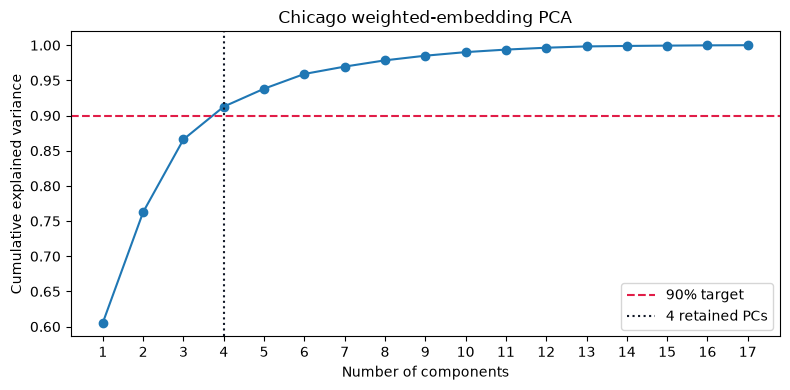

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pca_parameters.component, pca_parameters.cumulative_variance, marker='o')
ax.axhline(.90, color='#E11D48', linestyle='--', label='90% target')
ax.axvline(retained, color='#111827', linestyle=':', label=f'{retained} retained PCs')
ax.set(xlabel='Number of components', ylabel='Cumulative explained variance',
       title='Chicago weighted-embedding PCA')
ax.set_xticks(pca_parameters.component)
ax.legend()
plt.tight_layout()
plt.show()

## 10. Join names, boundaries, scores, and distances

The Curio dashboard-data node pairs the 77 PCA rows with Chicago Community Area names and boundaries. Each row holds PC1/PC2 plus its retained-PCA distance to every possible selected area. The polygon is stored as GeoJSON in a plain DataFrame so Curio's Vega nodes can consume it. This notebook runs the same preparation code, then turns those geometries into a GeoDataFrame for Python plotting.

In [24]:
def prepare_similarity_views(arg):
    # Prepare one compact table for Curio's linked PCA, ranking, and map dashboard.
    # arg is (raw, pca_pairs, pca_parameters, pca_distance_matrix,
    #        pca_scores, pca_loadings) from the PCA model application node.
    import geopandas as gpd
    import numpy as np
    import pandas as pd
    from shapely import orient_polygons
    from shapely.geometry import mapping


    ids = [f'CHI:{number:02d}' for number in range(1, 78)]
    if not isinstance(arg, (tuple, list)) or len(arg) != 6:
        raise ValueError('Expected the six-part PCA model application output')
    raw, pca_pairs, _pca_parameters, matrix, scores, _pca_loadings = arg

    if not isinstance(raw, pd.DataFrame) or raw.unit_id.tolist() != ids:
        raise ValueError('Raw model rows must be ordered CHI:01–CHI:77')
    if not isinstance(scores, pd.DataFrame) or not {'unit_id', 'PC1', 'PC2'}.issubset(scores):
        raise ValueError('PCA scores must contain unit_id, PC1, and PC2')
    if scores.unit_id.tolist() != ids:
        raise ValueError('PCA score rows must be ordered CHI:01–CHI:77')
    coordinates = scores[['PC1', 'PC2']].to_numpy(dtype=float)
    if not np.isfinite(coordinates).all():
        raise ValueError('PCA plot coordinates must be finite')

    if not isinstance(matrix, pd.DataFrame) or matrix.shape != (77, 78):
        raise ValueError('Expected a 77-by-77 PCA distance matrix with explicit IDs')
    if matrix.unit_id.tolist() != ids or matrix.columns.tolist() != ['unit_id'] + ids:
        raise ValueError('PCA distance matrix must be ordered CHI:01–CHI:77 on both axes')
    matrix = matrix.set_index('unit_id')
    distance_values = matrix.to_numpy(dtype=float)
    if not np.isfinite(distance_values).all() or (distance_values < -1e-10).any():
        raise ValueError('PCA distances must be finite and nonnegative')
    if not np.allclose(distance_values, distance_values.T, rtol=0, atol=1e-10):
        raise ValueError('PCA distance matrix must be symmetric')
    if not np.allclose(np.diag(distance_values), 0, rtol=0, atol=1e-10):
        raise ValueError('PCA self-distances must be zero')

    if not isinstance(pca_pairs, pd.DataFrame) or len(pca_pairs) != 2926:
        raise ValueError('Expected 2,926 unordered PCA pair distances')
    if not {'unit_id_a', 'unit_id_b', 'distance'}.issubset(pca_pairs):
        raise ValueError('PCA pairs must contain both unit IDs and distance')
    lookup = {unit_id: index for index, unit_id in enumerate(ids)}
    try:
        row_a = pca_pairs.unit_id_a.map(lookup).to_numpy(dtype=int)
        row_b = pca_pairs.unit_id_b.map(lookup).to_numpy(dtype=int)
    except (TypeError, ValueError) as exc:
        raise ValueError('PCA pairs contain an unknown Community Area ID') from exc
    if not np.array_equal(row_a, np.triu_indices(77, 1)[0]) or not np.array_equal(
            row_b, np.triu_indices(77, 1)[1]):
        raise ValueError('PCA pairs must follow strict upper-triangle ID order')
    if not np.allclose(pca_pairs.distance.to_numpy(dtype=float),
                       distance_values[row_a, row_b], rtol=1e-10, atol=1e-10):
        raise ValueError('PCA pairs disagree with the distance matrix')

    areas = gpd.read_file(curio_dataset_path('data.cityofchicago.community-areas-sideseeing'))
    if len(areas) != 77 or not {'area_numbe', 'community', 'geometry'}.issubset(areas):
        raise ValueError('Expected the 77 Community Area polygons with IDs and names')
    if areas.crs is None:
        raise ValueError('Community Area boundaries have no coordinate reference system')
    numbers = pd.to_numeric(areas.area_numbe, errors='raise').astype(int)
    if numbers.isna().any() or set(numbers.tolist()) != set(range(1, 78)):
        raise ValueError('Community Area boundaries must have IDs 1–77 exactly once')
    areas = areas.assign(_number=numbers).sort_values('_number').reset_index(drop=True)
    areas = areas.to_crs(4326)
    if areas.geometry.isna().any() or areas.geometry.is_empty.any() or not areas.geometry.is_valid.all():
        raise ValueError('Community Area boundaries contain empty or invalid polygons')
    if areas.community.isna().any() or areas.community.astype(str).str.strip().eq('').any():
        raise ValueError('Community Area boundaries contain a blank name')

    # A plain DataFrame is deliberate: Curio's Vega adapter drops active geometry
    # when its input is a GeoDataFrame. GeoJSON geometry in an object column survives
    # Curio's DataFrame codec and is rendered by Vega-Lite's geoshape mark.
    dashboard = pd.DataFrame({
        'type': ['Feature'] * 77,
        'geometry': [mapping(orient_polygons(geom, exterior_cw=False)) for geom in areas.geometry],
        'unit_id': ids,
        'area_numbe': [f'{number:02d}' for number in range(1, 78)],
        'community': areas.community.astype(str).str.strip().tolist(),
        'PC1': coordinates[:, 0],
        'PC2': coordinates[:, 1],
    })
    for number, unit_id in enumerate(ids, start=1):
        dashboard[f'd_{number:02d}'] = distance_values[:, number - 1]

    if dashboard.shape != (77, 84):
        raise ValueError('Dashboard payload must have 77 rows and 84 columns')
    return dashboard

dashboard = prepare_similarity_views(pca)
print('Chart-ready rows and columns:', dashboard.shape)
display(dashboard[['unit_id','community','PC1','PC2','d_01']].head())

Chart-ready rows and columns: (77, 84)


,unit_id,community,PC1,PC2,d_01
0,CHI:01,ROGERS PARK,0.678825,-0.162913,0.000000
1,CHI:02,WEST RIDGE,0.221985,0.192264,0.584189
2,CHI:03,UPTOWN,0.338592,-0.627211,0.675950
3,CHI:04,LINCOLN SQUARE,0.131875,-0.204434,0.615428
4,CHI:05,NORTH CENTER,0.715028,-0.119064,0.140846


## 11. Three linked similarity views

Choose any Community Area below. The **PCA scatter** marks the selected area and its ten closest peers using the retained-space distance, not just visible PC1/PC2 separation. The **bar chart** orders those ten by distance and excludes the selected area. The **map** colors every other area from blue (closer) to red (farther) and outlines the selected boundary. Curio links separate Vega nodes through a selection pool; in this notebook one dropdown drives the same three calculations.

In [25]:
from shapely.geometry import shape
import ipywidgets as widgets

plot_areas = gpd.GeoDataFrame(
    dashboard[['unit_id','community']].copy(),
    geometry=dashboard.geometry.map(shape), crs='EPSG:4326'
).to_crs(26916)
score_plot = dashboard[['unit_id','community','PC1','PC2']].copy()
pca_distance_lookup = pca_distances.set_index('unit_id')
name_lookup = dict(zip(dashboard.unit_id, dashboard.community))

def show_similarity(anchor_id='CHI:01'):
    distance = pca_distance_lookup[anchor_id].astype(float)
    nearest = distance.drop(anchor_id).sort_values(kind='stable').head(10)
    nearest_ids = set(nearest.index)
    colors = ['#111827' if uid == anchor_id else '#E11D48' if uid in nearest_ids
              else '#94A3B8' for uid in score_plot.unit_id]
    sizes = [150 if uid == anchor_id else 85 if uid in nearest_ids else 32
             for uid in score_plot.unit_id]

    fig = plt.figure(figsize=(17, 10))
    grid = fig.add_gridspec(2, 2, width_ratios=(1, 1.2), hspace=.35, wspace=.18)
    ax_pca = fig.add_subplot(grid[0, 0])
    ax_bar = fig.add_subplot(grid[1, 0])
    ax_map = fig.add_subplot(grid[:, 1])

    ax_pca.scatter(score_plot.PC1, score_plot.PC2, c=colors, s=sizes,
                   edgecolors='white', linewidths=.6, alpha=.9)
    chosen = score_plot.loc[score_plot.unit_id.eq(anchor_id)].iloc[0]
    ax_pca.annotate(chosen.community, (chosen.PC1, chosen.PC2),
                    xytext=(6, 6), textcoords='offset points', weight='bold')
    ax_pca.set(xlabel='PC1', ylabel='PC2', title='2D PCA: selected and nearest ten')

    ordered = nearest.rename_axis('unit_id').reset_index(name='distance')
    ordered['community'] = ordered.unit_id.map(name_lookup)
    ax_bar.barh(ordered.community, ordered.distance, color='#2A66B7')
    ax_bar.invert_yaxis()
    ax_bar.set(xlabel='Retained PCA distance (lower = closer)',
               title='Ten closest neighborhoods')

    mapped = plot_areas.merge(distance.rename('distance'),
                              left_on='unit_id', right_index=True, validate='one_to_one')
    mapped.plot(column='distance', cmap='turbo', ax=ax_map, legend=True,
                edgecolor='white', linewidth=.45)
    boundary = mapped.loc[mapped.unit_id.eq(anchor_id)]
    boundary.boundary.plot(ax=ax_map, color='white', linewidth=4)
    boundary.boundary.plot(ax=ax_map, color='#111827', linewidth=2)
    ax_map.set(title='Chicago similarity heatmap', aspect='equal')
    ax_map.axis('off')
    fig.suptitle(f'{name_lookup[anchor_id]} ({anchor_id})', fontsize=17, weight='bold')
    plt.show()
    display(ordered[['community','unit_id','distance']].assign(rank=range(1, 11)))

area_selector = widgets.Dropdown(
    options=[(f'{name_lookup[uid]} ({uid})', uid) for uid in dashboard.unit_id],
    value='CHI:01', description='Community Area:',
    layout=widgets.Layout(width='430px'), style={'description_width': 'initial'})
display(area_selector, widgets.interactive_output(show_similarity, {'anchor_id': area_selector}))

Dropdown(description='Community Area:', layout=Layout(width='430px'), options=(('ROGERS PARK (CHI:01)', 'CHI:0…

Output()

## Reading this beside the São Paulo notebook

Compare the feature definitions, eligible entities, dates, denominators, transformations, family weights, and PCA retention rule before comparing rankings. The Chicago notebook includes BV and uses eight families, whereas the São Paulo reference has its own accepted coordinate set. A similar-looking scatter or map does not make the two cities' raw features interchangeable. The Chicago result here is a **first Chicago-only candidate**; cross-city acceptance requires matched definitions and paired source review.